In [1]:
import pandas as pd

In [11]:
folderPath = "/mnt/d/Personal project/DeepLearning/nnForGraphs/attackClassifier/UNSW-NB15/"

In [12]:
dataDF = pd.read_csv(f"{folderPath}UNSW-NB15_1_cleaned_encoded.csv")

In [13]:
dataDF.head()

,Unnamed: 0,srcip,dstip,sport,dsport,proto,state,dur,sbytes,dbytes,Spkts,Dpkts,Sload,Dload,sttl,dttl,Label
0,0,59.166.0.0,149.171.126.6,1390.0,53.0,120,2,0.001055,132,164,2,2,500473.93750,621800.93750,31,29,0
1,1,59.166.0.0,149.171.126.9,33661.0,1024.0,120,2,0.036133,528,304,4,4,87676.08594,50480.17188,31,29,0
2,2,59.166.0.6,149.171.126.7,1464.0,53.0,120,2,0.001119,146,178,2,2,521894.53130,636282.37500,31,29,0
3,3,59.166.0.5,149.171.126.5,3593.0,53.0,120,2,0.001209,132,164,2,2,436724.56250,542597.18750,31,29,0
4,4,59.166.0.3,149.171.126.0,49664.0,53.0,120,2,0.001169,146,178,2,2,499572.25000,609067.56250,31,29,0


In [14]:
dataDF.drop(columns=["Unnamed: 0"] , inplace=True)

In [15]:
import networkx as netx

graph = netx.MultiDiGraph()

In [16]:
src = dataDF['srcip'].to_list()
dest = dataDF['dstip'].to_list()

In [17]:
graph.add_nodes_from(src)
graph.add_nodes_from(dest)

In [18]:
import pandas as pd

src_features = dataDF.groupby("srcip").agg(
    out_degree=("srcip", "count"),
    avg_sbytes=("sbytes", "mean"),
    avg_spkts=("Spkts", "mean"),
    avg_sload=("Sload", "mean"),
    avg_sttl=("sttl", "mean"),
    avg_duration=("dur", "mean")
)

dst_features = dataDF.groupby("dstip").agg(
    in_degree=("dstip", "count"),
    avg_dbytes=("dbytes", "mean"),
    avg_dpkts=("Dpkts", "mean"),
    avg_dload=("Dload", "mean"),
    avg_dttl=("dttl", "mean")
)

In [19]:
src_features

,out_degree,avg_sbytes,avg_spkts,avg_sload,avg_sttl,avg_duration
srcip,,,,,,
10.40.170.2,306,47.202614,1.026144,1.603725e-01,0.000000,1.568394
10.40.182.1,548,242.759124,4.324818,3.175249e+01,0.572993,39.194884
10.40.182.3,306,47.202614,1.026144,1.603725e-01,0.000000,1.568394
10.40.85.1,568,246.799296,4.302817,7.848922e+01,1.228873,25.011826
10.40.85.30,300,183.080000,3.980000,3.231601e+04,0.000000,30.167794
149.171.126.0,46,29777.652174,36.804348,2.314602e+06,29.152174,0.334283
149.171.126.1,72,60718.847222,53.763889,1.296364e+07,29.069444,0.693978
149.171.126.10,3,362.666667,4.666667,5.001221e+06,188.666667,0.198172
149.171.126.11,16,525.375000,2.875000,1.168129e+08,240.000000,0.318213


In [20]:
dst_features

,in_degree,avg_dbytes,avg_dpkts,avg_dload,avg_dttl
dstip,,,,,
10.40.170.2,306,0.000000,0.000000,0.000000e+00,0.000000
10.40.182.3,540,44.125926,0.959259,4.591750e+00,0.000000
10.40.85.1,300,111.440000,3.980000,1.967061e+04,0.000000
10.40.85.30,248,100.903226,2.193548,1.088674e+01,0.000000
149.171.126.0,21062,46321.163185,54.044535,3.140597e+06,28.988320
149.171.126.1,20796,47074.604924,54.708454,3.076398e+06,28.980573
149.171.126.10,1975,5642.497215,11.311899,2.655036e+04,182.486076
149.171.126.11,1796,7154.362472,14.414254,3.951509e+04,199.309577
149.171.126.12,4815,5621.067497,6.831983,1.310109e+04,51.681205


In [21]:
node_features = src_features.join(dst_features, how="outer")
node_features = node_features.fillna(0)

In [22]:
for node, features in node_features.iterrows():
    if graph.has_node(node):
        graph.nodes[node].update(features.to_dict())

In [23]:
print(graph.nodes["59.166.0.0"])

{'out_degree': 20996.0, 'avg_sbytes': 4397.46808915984, 'avg_spkts': 40.68860735378167, 'avg_sload': 1031870.2738395786, 'avg_sttl': 31.001476471708898, 'avg_duration': 0.545479584825681, 'in_degree': 63.0, 'avg_dbytes': 2156.8571428571427, 'avg_dpkts': 25.952380952380953, 'avg_dload': 464685.9719018254, 'avg_dttl': 26.634920634920636}


In [24]:
node_features.head()

,out_degree,avg_sbytes,avg_spkts,avg_sload,avg_sttl,avg_duration,in_degree,avg_dbytes,avg_dpkts,avg_dload,avg_dttl
10.40.170.2,306.0,47.202614,1.026144,0.160372,0.000000,1.568394,306.0,0.000000,0.000000,0.000000,0.0
10.40.182.1,548.0,242.759124,4.324818,31.752487,0.572993,39.194884,0.0,0.000000,0.000000,0.000000,0.0
10.40.182.3,306.0,47.202614,1.026144,0.160372,0.000000,1.568394,540.0,44.125926,0.959259,4.591750,0.0
10.40.85.1,568.0,246.799296,4.302817,78.489220,1.228873,25.011826,300.0,111.440000,3.980000,19670.611403,0.0
10.40.85.30,300.0,183.080000,3.980000,32316.005161,0.000000,30.167794,248.0,100.903226,2.193548,10.886741,0.0


In [25]:
# Add nodes with attributes
for node, features in node_features.iterrows():
    graph.add_node(node, **features.to_dict())

# Add edges
for _, row in dataDF.iterrows():
    graph.add_edge(
        row["srcip"],
        row["dstip"],
        sport=row["sport"],
        dsport=row["dsport"],
        proto=row["proto"],
        state=row["state"],
        dur=row["dur"],
        sbytes=row["sbytes"],
        dbytes=row["dbytes"],
        Label=row["Label"]
    )

In [26]:
print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())

print("Average degree:",
      sum(dict(graph.degree()).values()) / graph.number_of_nodes())

print("Self loops:",
      netx.number_of_selfloops(graph))

print("Connected Components:",
      netx.number_weakly_connected_components(graph))

Nodes: 43
Edges: 240720
Average degree: 11196.279069767443
Self loops: 721
Connected Components: 4


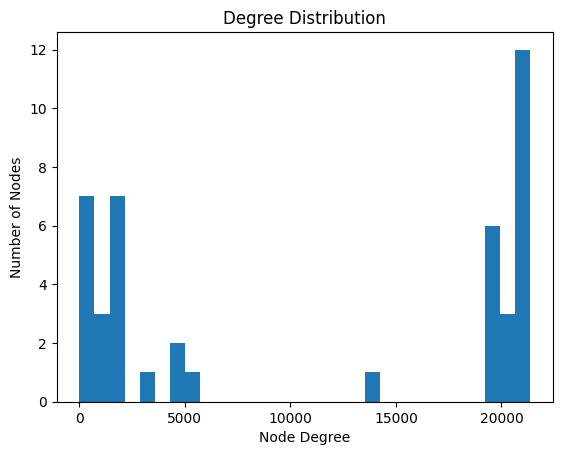

In [27]:
degrees = [d for _, d in graph.degree()]

import matplotlib.pyplot as plt

plt.hist(degrees, bins=30)
plt.xlabel("Node Degree")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution")
plt.show()

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as funct
from torch_geometric.nn import GCNConv

/mnt/d/Personal project/DeepLearning/nnForGraphs/attackClassifier/gcn/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "cpu"
)
print(f"Using device: {device}")


Using device: cuda


In [30]:
from torch_geometric.utils import from_networkx

data = from_networkx(graph).to(device)

In [31]:
print(data)

Data(edge_index=[2, 240720], out_degree=[43], avg_sbytes=[43], avg_spkts=[43], avg_sload=[43], avg_sttl=[43], avg_duration=[43], in_degree=[43], avg_dbytes=[43], avg_dpkts=[43], avg_dload=[43], avg_dttl=[43], sport=[240720], dsport=[240720], proto=[240720], state=[240720], dur=[240720], sbytes=[240720], dbytes=[240720], Label=[240720], num_nodes=43)


In [32]:
from sklearn.preprocessing import StandardScaler

scalerNode = StandardScaler()

node_features[:] = scalerNode.fit_transform(node_features)

data.x = torch.tensor(
    node_features.values,
    dtype=torch.float
)

In [33]:
edge_features = []
edge_labels = []

for _, _, attr in graph.edges(data=True):

    edge_features.append([
        attr["dur"],
        attr["sbytes"],
        attr["dbytes"],
        attr["sport"],
        attr["dsport"],
        attr["proto"],
        attr["state"]
    ])

    edge_labels.append(attr["Label"])

In [34]:
scalerEdges = StandardScaler()
edge_features[:] = scalerEdges.fit_transform(edge_features)

In [35]:
data.edge_attr = torch.tensor(
    edge_features,
    dtype=torch.float
).to(device)

data.edge_label = torch.tensor(
    edge_labels,
    dtype=torch.long
).to(device)

/tmp/ipykernel_37949/1485769197.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  data.edge_attr = torch.tensor(


In [36]:
from sklearn.model_selection import train_test_split
edgeIndx = torch.arange(data.edge_index.size(1))
trainIndx , testIndx = train_test_split(edgeIndx , test_size=0.25 , random_state=31 , stratify=data.edge_label.cpu())

In [37]:
class EdgeGCN(nn.Module):

    def __init__(
        self,
        node_feature_dim,
        edge_feature_dim,
        hidden_dim=64,
        embedding_dim=32
    ):
        super().__init__()

        # GCN
        self.conv1 = GCNConv(node_feature_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, embedding_dim)

        # Edge Classifier
        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim * 2 + edge_feature_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self,x,edge_index,edge_attr):

        x = self.conv1(x, edge_index)
        x = funct.relu(x)

        x = self.conv2(x, edge_index)
        x = funct.relu(x)

        src = x[edge_index[0]]

        dst = x[edge_index[1]]

        edge_representation = torch.cat(

            [
                src,
                dst,
                edge_attr
            ],

            dim=1
        )

        out = self.classifier(edge_representation)

        return out

In [38]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EdgeGCN(

    node_feature_dim=data.num_node_features,

    edge_feature_dim=data.edge_attr.shape[1]

).to(device)

In [39]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001
)

criterion = nn.CrossEntropyLoss()

In [40]:
data = data.to(device)

In [41]:
epochs = 250

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    out = model(

        data.x,

        data.edge_index,

        data.edge_attr
    )

    loss = criterion(

        out[trainIndx],
        data.edge_label[trainIndx]
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1:03d}"
        f" Loss : {loss.item():.4f}"
    )

Epoch 001 Loss : 0.7155
Epoch 002 Loss : 0.7005
Epoch 003 Loss : 0.6865
Epoch 004 Loss : 0.6730
Epoch 005 Loss : 0.6600
Epoch 006 Loss : 0.6473
Epoch 007 Loss : 0.6345
Epoch 008 Loss : 0.6211
Epoch 009 Loss : 0.6067
Epoch 010 Loss : 0.5911
Epoch 011 Loss : 0.5739
Epoch 012 Loss : 0.5546
Epoch 013 Loss : 0.5333
Epoch 014 Loss : 0.5099
Epoch 015 Loss : 0.4848
Epoch 016 Loss : 0.4579
Epoch 017 Loss : 0.4293
Epoch 018 Loss : 0.3992
Epoch 019 Loss : 0.3680
Epoch 020 Loss : 0.3363
Epoch 021 Loss : 0.3046
Epoch 022 Loss : 0.2737
Epoch 023 Loss : 0.2442
Epoch 024 Loss : 0.2168
Epoch 025 Loss : 0.1919
Epoch 026 Loss : 0.1700
Epoch 027 Loss : 0.1512
Epoch 028 Loss : 0.1357
Epoch 029 Loss : 0.1231
Epoch 030 Loss : 0.1131
Epoch 031 Loss : 0.1052
Epoch 032 Loss : 0.0992
Epoch 033 Loss : 0.0945
Epoch 034 Loss : 0.0905
Epoch 035 Loss : 0.0868
Epoch 036 Loss : 0.0834
Epoch 037 Loss : 0.0801
Epoch 038 Loss : 0.0770
Epoch 039 Loss : 0.0739
Epoch 040 Loss : 0.0711
Epoch 041 Loss : 0.0686
Epoch 042 Loss :

In [42]:
model.eval()

with torch.no_grad():

    logits = model(

        data.x,

        data.edge_index,

        data.edge_attr
    )

    prediction = logits[testIndx].argmax(dim=1)

In [43]:
correct = (

    prediction == data.edge_label[testIndx]

).sum()

accuracy = correct / len(data.edge_label[testIndx])

print(
    accuracy.item()
)

0.9833499193191528


In [44]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    data.edge_label[testIndx].cpu(),
    prediction.cpu()
))

print(confusion_matrix(
    data.edge_label[testIndx].cpu(),
    prediction.cpu()
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     54626
           1       0.86      0.98      0.92      5554

    accuracy                           0.98     60180
   macro avg       0.93      0.98      0.95     60180
weighted avg       0.99      0.98      0.98     60180

[[53727   899]
 [  103  5451]]


In [45]:
prob = torch.softmax(out[testIndx], dim=1)[:,1]

print(
    roc_auc_score(
        data.edge_label[testIndx].cpu(),
        prob.cpu()
    )
)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.